# Figure 6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
all_seq = pd.read_excel('../data/targetgan_55296.xlsx')

# 2. Construct Motif Counts
motif_counts_target = pd.DataFrame(0, index=[i for i in range(55296)], columns=['seqlet_%s'%i for i in range(13)])
# Optimized counting
for i in range(fimo_target.shape[0]-3): 
    s = fimo_target['motif_id'][i].split('motif_pfm')[-1]
    motif = 'seqlet_%s'%s
    seq = int(fimo_target['sequence_name'][i])
    motif_counts_target.at[seq, motif] += 1

# 3. Train Linear Regression
X = np.array(motif_counts_target.values)
y = np.array(all_seq['the predicted promoter strength'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2024)
LR_targetgan = LinearRegression()
LR_targetgan.fit(X_train, y_train)

y_pre_train = LR_targetgan.predict(X_train)
y_pre_test = LR_targetgan.predict(X_test)

print("lr.coef_: {}".format(LR_targetgan.coef_))
print("Training PCC: {}".format(pearsonr(y_pre_train, y_train)[0]))
print("Test PCC: {}".format(pearsonr(y_test, y_pre_test)[0]))

# 4. Load Contribution Scores
seqlet_contribution_dict = {}
score_file_path = "./data_for_plot/seqlet_scores.txt"

try:
    with open(score_file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(":")
            if len(parts) >= 2:
                key_part = parts[0].strip()
                value_part = ":".join(parts[1:]).strip()
                seqlet_contribution_dict[key_part] = float(value_part)
except FileNotFoundError:
    print(f"Warning: {score_file_path} not found.")

# 5. Prepare Common Variables for Plotting
motif_labels = [
    "Seqlet0(TATAAA)", "Seqlet1(TATATA)", "Seqlet2(AGL27)", "Seqlet3(TCP19)", 
    "Seqlet4", "Seqlet5(AZF1)", "Seqlet6(ZAT10)", "Seqlet7(AT3G46070)", 
    "Seqlet8(AHL20)", "Seqlet9(HDG11)", "Seqlet10(TSO1)", "Seqlet11(ANL2)", "Seqlet12(ASR1)"
]

avg_scores = []
for i in range(13):
    found = False
    for k, v in seqlet_contribution_dict.items():
        if f"Seqlet{i}" in k:
            avg_scores.append(v)
            found = True
            break
    if not found:
        print(f"Seqlet{i} score not found")
        avg_scores.append(0.0)

coefs = LR_targetgan.coef_
colors = ['#ef7c76' if c > 0 else '#6badd6' for c in coefs]

X shape: (55296, 13)
y shape: (55296,)
lr.coef_: [ 1.37311205  0.14503411  0.64619264  0.18278742  0.10822726 -0.46929926
 -0.2836701  -0.72629092 -0.2323081  -0.23664556 -0.20548747 -0.56816156
 -0.67952203]
Training PCC: 0.8363322120398211
Test PCC: 0.8406524782210231


### 1. Linear Regression Model Performance
Here we evaluate the performance of the Linear Regression model on the test set. The plot shows the correlation between the actual predicted promoter strength (from TargetGAN's predictor) and the values predicted by our simple linear regression model based on motif counts.

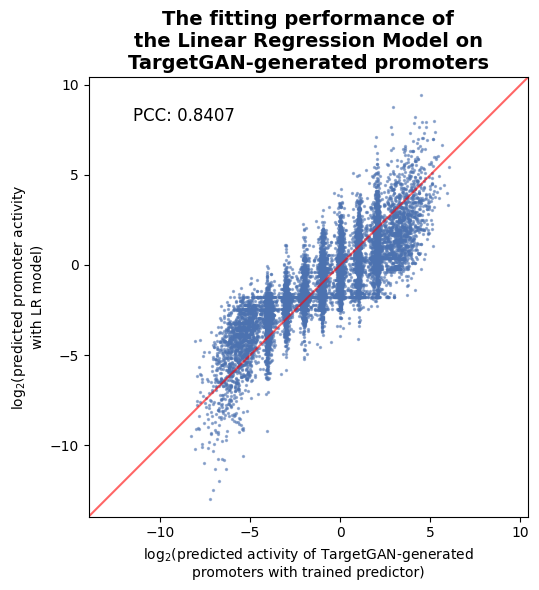

In [3]:
# Performance Plot
test_pcc = pearsonr(y_test, y_pre_test)[0]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pre_test, s=2, alpha=0.5, c='#4c72b0')

# Diagonal Line
min_val = min(y_test.min(), y_pre_test.min()) - 1
max_val = max(y_test.max(), y_pre_test.max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'r-', alpha=0.6, linewidth=1.5)

# Set consistent axis limits
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.title("The fitting performance of\nthe Linear Regression Model on\nTargetGAN-generated promoters", fontsize=14, fontweight='bold')
plt.xlabel("log$_2$(predicted activity of TargetGAN-generated\npromoters with trained predictor)", fontsize=10)
plt.ylabel("log$_2$(predicted promoter activity\nwith LR model)", fontsize=10)
plt.text(0.1, 0.9, f"PCC: {test_pcc:.4f}", transform=plt.gca().transAxes, fontsize=12)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

### 2. Learned Motif Weights
The bar chart below displays the regression coefficients (weights) learned by the Linear Regression model for each seqlet motif. Positive weights (red) indicate a positive contribution to promoter strength, while negative weights (blue) indicate a suppressive effect.

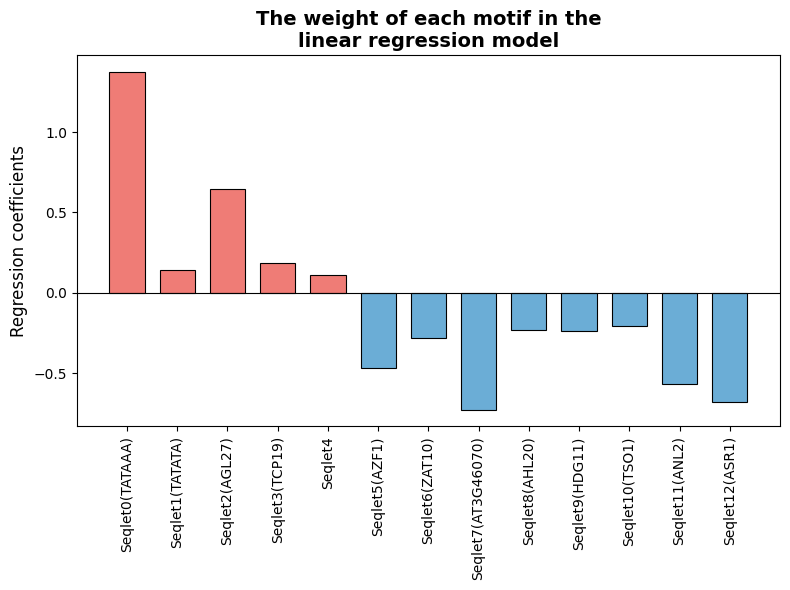

In [4]:
# Motif Weights Plot
plt.figure(figsize=(8, 6))
plt.bar(range(13), coefs, color=colors, edgecolor='black', linewidth=0.8, width=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(range(13), motif_labels, rotation=90, fontsize=10)
plt.ylabel("Regression coefficients", fontsize=12)
plt.title("The weight of each motif in the\nlinear regression model", fontsize=14, fontweight='bold')
plt.xlim(-1, 13)
plt.tight_layout()
plt.show()

### 3. Correlation Analysis between Coefficients and Contribution Scores
We examine the relationship between the Linear Regression coefficients and the DeepLIFT contribution scores to validate if motifs identified as important by the model also have high importance scores.

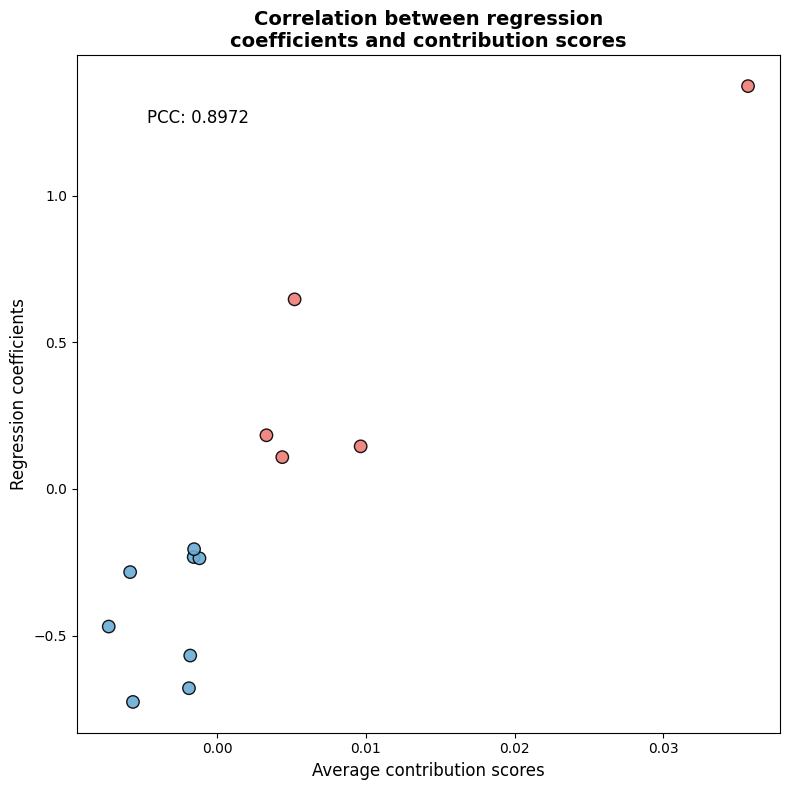

In [8]:
# Correlation Plot
corr_pcc = pearsonr(avg_scores, coefs)[0]

plt.figure(figsize=(8, 8))
plt.scatter(avg_scores, coefs, c=colors, s=80, edgecolor='black', alpha=0.9)
plt.xlabel("Average contribution scores", fontsize=12)
plt.ylabel("Regression coefficients", fontsize=12)
plt.title("Correlation between regression\ncoefficients and contribution scores", fontsize=14, fontweight='bold')
plt.text(0.1, 0.9, f"PCC: {corr_pcc:.4f}", transform=plt.gca().transAxes, fontsize=12)

# # Annotate points
# for i, txt in enumerate(motif_labels):
#     xytext = (5, 5) if coefs[i] > 0 else (5, -15) 
#     plt.annotate(txt, (avg_scores[i], coefs[i]), xytext=xytext, textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### 4. Transfer Performance on WGAN-GP Generated Promoters
We apply the trained Linear Regression model to predict the activity of promoters generated by WGAN-GP and compare it with the TargetGAN predictor's output to assess transferability.

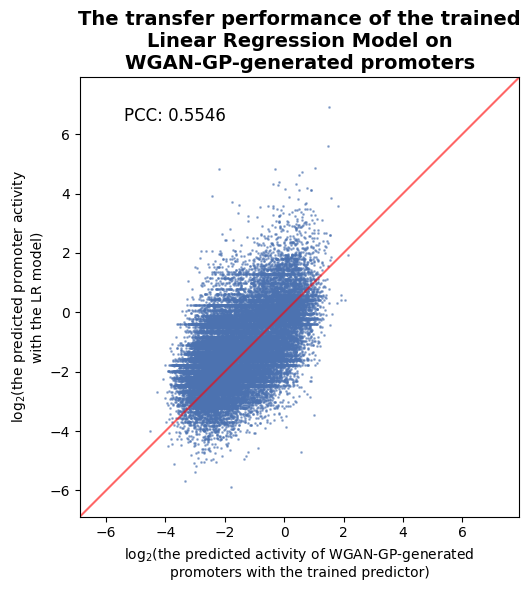

In [10]:
# WGAN-GP Transfer Plot
fimo_gan = pd.read_csv('./data_for_plot/fimo_gan.tsv', sep='\t')
gan_seq = pd.read_excel('../data/WGAN_GP_gen_pro.xlsx')

motif_counts_gan = pd.DataFrame(0, index=range(len(gan_seq)), columns=['seqlet_%s'%i for i in range(13)])

# Using itertuples for faster iteration
for row in fimo_gan.itertuples():
    try:
        # Check for footer/invalid lines if any
        if not isinstance(row.motif_id, str): continue 
        s = row.motif_id.split('motif_pfm')[-1]
        motif = 'seqlet_%s'%s
        seq = int(row.sequence_name)
        # Ensure index is within bounds
        if seq < len(motif_counts_gan):
            motif_counts_gan.at[seq, motif] += 1
    except (ValueError, IndexError):
        continue

X_gan = np.array(motif_counts_gan.values)
y_gan = np.array(gan_seq['the predicted enrichment'])

y_pre_gan = LR_targetgan.predict(X_gan)
pcc_gan = pearsonr(y_gan, y_pre_gan)[0]

plt.figure(figsize=(6, 6))
plt.scatter(y_gan, y_pre_gan, s=1, alpha=0.5, c='#4c72b0')

min_val = min(y_gan.min(), y_pre_gan.min()) - 1
max_val = max(y_gan.max(), y_pre_gan.max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'r-', alpha=0.6, linewidth=1.5)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.title("The transfer performance of the trained\nLinear Regression Model on\nWGAN-GP-generated promoters", fontsize=14, fontweight='bold')
plt.xlabel("log$_2$(the predicted activity of WGAN-GP-generated\npromoters with the trained predictor)", fontsize=10)
plt.ylabel("log$_2$(the predicted promoter activity\nwith the LR model)", fontsize=10)
plt.text(0.1, 0.9, f"PCC: {pcc_gan:.4f}", transform=plt.gca().transAxes, fontsize=12)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

### 5. Transfer Performance on Natural Promoters
Finally, we test the trained model on natural (native) promoter sequences to evaluate its generalization capability to real biological data.

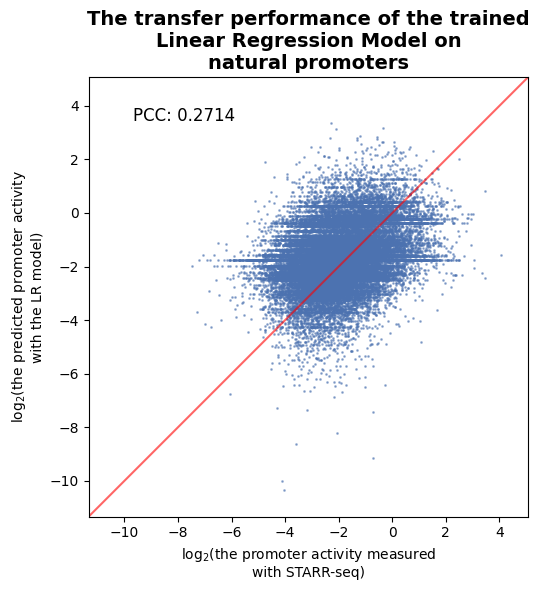

In [12]:
# Native Transfer Plot
fimo_native = pd.read_csv('./data_for_plot/fimo_nat.tsv', sep='\t')
native_seq = pd.read_excel('../data/Natural_promoters.xlsx') 

motif_counts_native = pd.DataFrame(0, index=range(len(native_seq)), columns=['seqlet_%s'%i for i in range(13)])

for row in fimo_native.itertuples():
    try:
        if not isinstance(row.motif_id, str): continue
        s = row.motif_id.split('motif_pfm')[-1]
        motif = 'seqlet_%s'%s
        seq = int(row.sequence_name)
        if seq < len(motif_counts_native):
            motif_counts_native.at[seq, motif] += 1
    except: continue

X_nat = np.array(motif_counts_native.values)
y_nat = np.array(native_seq['enrichment'])

y_pre_nat = LR_targetgan.predict(X_nat)
pcc_nat = pearsonr(y_nat, y_pre_nat)[0]

plt.figure(figsize=(6, 6))
plt.scatter(y_nat, y_pre_nat, s=1, alpha=0.5, c='#4c72b0')

min_val = min(y_nat.min(), y_pre_nat.min()) - 1
max_val = max(y_nat.max(), y_pre_nat.max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'r-', alpha=0.6, linewidth=1.5)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.title("The transfer performance of the trained\nLinear Regression Model on\nnatural promoters", fontsize=14, fontweight='bold')
plt.xlabel("log$_2$(the promoter activity measured\nwith STARR-seq)", fontsize=10)
plt.ylabel("log$_2$(the predicted promoter activity\nwith the LR model)", fontsize=10)
plt.text(0.1, 0.9, f"PCC: {pcc_nat:.4f}", transform=plt.gca().transAxes, fontsize=12)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()